<a href="https://colab.research.google.com/github/gustavocostamiguel/AulaPacote/blob/main/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importa a biblioteca pandas para manipulação de dados em DataFrames.
import pandas as pd
# Importa a biblioteca numpy para operações numéricas, especialmente com arrays.
import numpy as np
# Importa train_test_split para dividir os dados em conjuntos de treino e teste.
from sklearn.model_selection import train_test_split
# Importa GaussianNB, o classificador Naive Bayes Gaussiano.
from sklearn.naive_bayes import GaussianNB
# Importa LabelEncoder para codificar rótulos categóricos em numéricos.
from sklearn.preprocessing import LabelEncoder
# Importa métricas de avaliação do modelo, como acurácia, precisão, recall, f1-score e relatório de classificação.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# Importa ConfusionMatrix para visualização da matriz de confusão.
from yellowbrick.classifier import ConfusionMatrix

In [ ]:
# Esta célula está vazia e pode ser usada para código adicional, se necessário.

In [ ]:
# Importa a biblioteca pandas para manipulação de dados em DataFrames.
import pandas as pd
# Carrega o arquivo CSV 'insurance.csv' em um DataFrame pandas, mantendo valores 'NA' como estão (sem converter para NaN).
base = pd.read_csv("insurance.csv",keep_default_na=False)
# Exibe as primeiras 5 linhas do DataFrame para uma visualização inicial dos dados.
base.head()

,Unnamed: 0,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,Mileage,Antilock,DrivingSkill,SeniorTrain,ThisCarCost,Theft,CarValue,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,1,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,TwentyThou,False,SubStandard,False,TenThou,False,FiveThou,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,2,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,Normal,TwentyThou,False,Normal,True,Thousand,False,TenThou,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,3,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,Excellent,Domino,True,Normal,False,Thousand,False,TwentyThou,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,4,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,Normal,FiftyThou,False,Normal,False,Thousand,False,FiveThou,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,5,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,FiftyThou,False,SubStandard,False,TenThou,False,FiveThou,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [ ]:
# Remove a coluna 'Unnamed: 0' do DataFrame 'base', pois geralmente é um índice extra indesejado do CSV.
base = base.drop(columns=['Unnamed: 0'])
# Exibe as primeiras 5 linhas do DataFrame novamente para verificar se a coluna foi removida com sucesso.
base.head()

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,Mileage,Antilock,DrivingSkill,SeniorTrain,ThisCarCost,Theft,CarValue,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,TwentyThou,False,SubStandard,False,TenThou,False,FiveThou,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,Normal,TwentyThou,False,Normal,True,Thousand,False,TenThou,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,Excellent,Domino,True,Normal,False,Thousand,False,TwentyThou,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,Normal,FiftyThou,False,Normal,False,Thousand,False,FiveThou,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,FiftyThou,False,SubStandard,False,TenThou,False,FiveThou,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [31]:
# Faz previsões no conjunto de teste
previsoes = modelo.predict(X_teste)

# Exibe as primeiras 10 previsões
print("Primeiras 10 previsões:", previsoes[:10])
print("Primeiros 10 valores reais (Y_teste):", Y_teste[:10])

Primeiras 10 previsões: ['Moderate' 'None' 'None' 'None' 'Severe' 'Moderate' 'None' 'Moderate'
 'Mild' 'Mild']
Primeiros 10 valores reais (Y_teste): ['Severe' 'None' 'None' 'None' 'Severe' 'Moderate' 'None' 'Moderate'
 'Mild' 'Mild']


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Avalia o desempenho do modelo
acuracia = accuracy_score(Y_teste, previsoes)
precisao = precision_score(Y_teste, previsoes, average='weighted', zero_division=0)
recall = recall_score(Y_teste, previsoes, average='weighted', zero_division=0)
f1 = f1_score(Y_teste, previsoes, average='weighted', zero_division=0)

print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Exibe o relatório de classificação detalhado
print("\nRelatório de Classificação:")
print(classification_report(Y_teste, previsoes, zero_division=0))

Acurácia: 0.8658
Precisão: 0.9245
Recall: 0.8658
F1-Score: 0.8449

Relatório de Classificação:
              precision    recall  f1-score   support

        Mild       0.92      0.74      0.82       553
    Moderate       0.39      0.92      0.55       473
        None       0.98      1.00      0.99      4294
      Severe       0.95      0.09      0.16       680

    accuracy                           0.87      6000
   macro avg       0.81      0.69      0.63      6000
weighted avg       0.92      0.87      0.84      6000



Matriz de Confusão salva como confusion_matrix.png


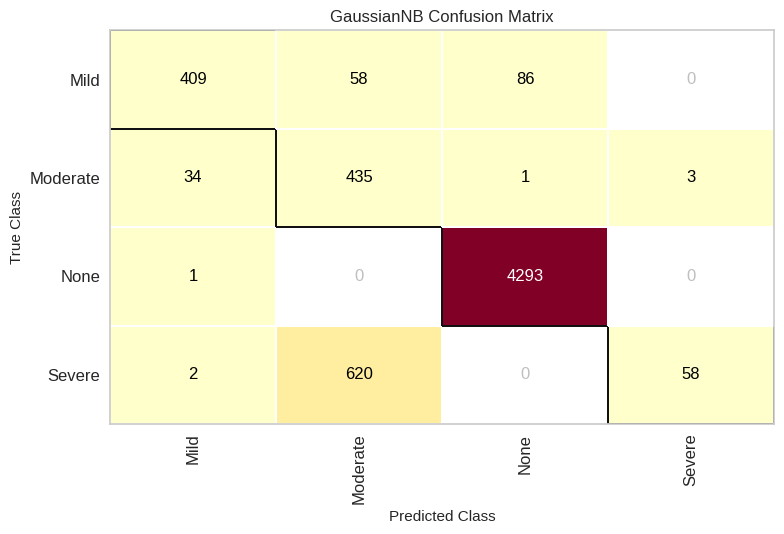

In [33]:
from yellowbrick.classifier import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np

# Obtém os rótulos únicos de Y_teste para o gráfico
classes = np.unique(Y_teste)

# Cria e plota a Matriz de Confusão
cm = ConfusionMatrix(modelo, classes=classes, is_fitted=True)
cm.fit(X_treinamento, Y_treinamento)
cm.score(X_teste, Y_teste)
cm.poof(outpath="confusion_matrix.png")
print("Matriz de Confusão salva como confusion_matrix.png")
plt.show()

In [34]:
# Faz previsões no conjunto de teste
previsoes = modelo.predict(X_teste)

# Exibe as primeiras 10 previsões
print("Primeiras 10 previsões:", previsoes[:10])
print("Primeiros 10 valores reais (Y_teste):", Y_teste[:10])

Primeiras 10 previsões: ['Moderate' 'None' 'None' 'None' 'Severe' 'Moderate' 'None' 'Moderate'
 'Mild' 'Mild']
Primeiros 10 valores reais (Y_teste): ['Severe' 'None' 'None' 'None' 'Severe' 'Moderate' 'None' 'Moderate'
 'Mild' 'Mild']


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Avalia o desempenho do modelo
acuracia = accuracy_score(Y_teste, previsoes)
precisao = precision_score(Y_teste, previsoes, average='weighted', zero_division=0)
recall = recall_score(Y_teste, previsoes, average='weighted', zero_division=0)
f1 = f1_score(Y_teste, previsoes, average='weighted', zero_division=0)

print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Exibe o relatório de classificação detalhado
print("\nRelatório de Classificação:")
print(classification_report(Y_teste, previsoes, zero_division=0))

Acurácia: 0.8658
Precisão: 0.9245
Recall: 0.8658
F1-Score: 0.8449

Relatório de Classificação:
              precision    recall  f1-score   support

        Mild       0.92      0.74      0.82       553
    Moderate       0.39      0.92      0.55       473
        None       0.98      1.00      0.99      4294
      Severe       0.95      0.09      0.16       680

    accuracy                           0.87      6000
   macro avg       0.81      0.69      0.63      6000
weighted avg       0.92      0.87      0.84      6000



Matriz de Confusão salva como confusion_matrix.png


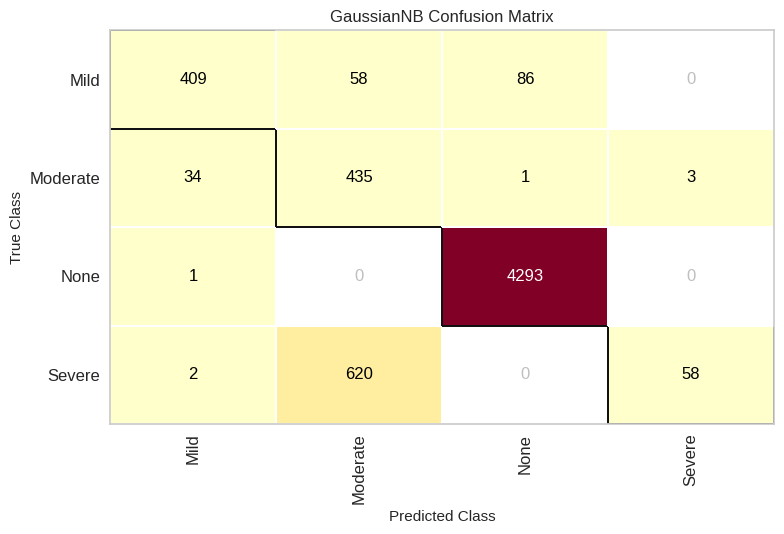

In [36]:
from yellowbrick.classifier import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np

# Obtém os rótulos únicos de Y_teste para o gráfico
classes = np.unique(Y_teste)

# Cria e plota a Matriz de Confusão
cm = ConfusionMatrix(modelo, classes=classes, is_fitted=True)
cm.fit(X_treinamento, Y_treinamento)
cm.score(X_teste, Y_teste)
cm.poof(outpath="confusion_matrix.png")
print("Matriz de Confusão salva como confusion_matrix.png")
plt.show()

In [ ]:
# Exibe o formato (número de linhas e colunas) do DataFrame 'base'.
# Isso ajuda a entender a dimensão dos dados com os quais estamos trabalhando.
base.shape

(20000, 27)

In [42]:
# Imprime a contagem de valores nulos para cada coluna no DataFrame 'base'.
# Isso é crucial para identificar se há dados ausentes que precisam ser tratados.
print(base.isnull().sum())

GoodStudent     0
Age             0
SocioEcon       0
RiskAversion    0
VehicleYear     0
ThisCarDam      0
RuggedAuto      0
Accident        0
MakeModel       0
DrivQuality     0
Mileage         0
Antilock        0
DrivingSkill    0
SeniorTrain     0
ThisCarCost     0
Theft           0
CarValue        0
HomeBase        0
AntiTheft       0
PropCost        0
OtherCarCost    0
OtherCar        0
MedCost         0
Cushioning      0
Airbag          0
ILiCost         0
DrivHist        0
dtype: int64


In [10]:
# Importa a biblioteca pandas para manipulação de dados em DataFrames.
import pandas as pd
# Carrega o arquivo CSV 'insurance.csv' em um DataFrame pandas, mantendo valores 'NA' como estão (sem converter para NaN).
base = pd.read_csv("insurance.csv",keep_default_na=False)
# Exibe as primeiras 5 linhas do DataFrame para uma visualização inicial dos dados.
base.head()

,Unnamed: 0,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,1,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,2,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,3,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,4,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,5,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [43]:
# Lista todos os arquivos e diretórios no ambiente atual do Colab.
# Usado para verificar a presença de arquivos como 'insurance.csv'.
!ls -F

confusion_matrix.png  insurance.csv  sample_data/


In [11]:
# Remove a coluna 'Unnamed: 0' do DataFrame 'base', pois geralmente é um índice extra indesejado do CSV.
base = base.drop(columns=['Unnamed: 0'])
# Exibe as primeiras 5 linhas do DataFrame novamente para verificar se a coluna foi removida com sucesso.
base.head()

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,Normal,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,Excellent,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [12]:
# Seleciona a 8ª coluna (índice 7) do DataFrame 'base' como a variável alvo (y) e converte para array numpy.
y = base.iloc[:,7].values
# Remove a 8ª coluna (índice 7) do DataFrame 'base' e seleciona as colunas restantes como as variáveis preditoras (x), convertendo para array numpy.
X = base.drop(base.columns[7], axis=1).values
# Exibe as primeiras linhas do array 'x' para verificar os dados das variáveis preditoras.
X

array([[False, 'Adult', 'Prole', ..., False, 'Thousand', 'Many'],
       [False, 'Senior', 'Prole', ..., True, 'Thousand', 'Zero'],
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'One'],
       ...,
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero']],
      dtype=object)

In [16]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
for i in range(X.shape[1]):
  if X[:,i].dtype == "object":
     X[:,i] = labelencoder.fit_transform(X[:,i])

In [44]:
# Exibe o array 'X' após a codificação de rótulos (Label Encoding).
# Isso mostra os dados das variáveis preditoras transformadas em formato numérico.
X

array([[0, 1, 1, ..., 0, 3, 0],
       [0, 2, 1, ..., 1, 3, 2],
       [0, 2, 2, ..., 1, 3, 1],
       ...,
       [0, 2, 2, ..., 1, 3, 2],
       [0, 1, 0, ..., 1, 3, 2],
       [0, 1, 0, ..., 1, 3, 2]], dtype=object)

In [23]:
from sklearn.model_selection import train_test_split
X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(X, y, test_size=0.3, random_state=0)

In [47]:
from sklearn.naive_bayes import GaussianNB # Importa o classificador Gaussian Naive Bayes.

# Inicializa o modelo Gaussian Naive Bayes.
modelo = GaussianNB()

# Treina o modelo usando os dados de treinamento.
# modelo.fit() ajusta o modelo aos dados, aprendendo os padrões entre X_treinamento e Y_treinamento.
modelo.fit(X_treinamento, Y_treinamento)

GaussianNB()

In [48]:
# Faz previsões no conjunto de teste utilizando o modelo treinado.
# modelo.predict() retorna as classes previstas para cada amostra em X_teste.
previsoes = modelo.predict(X_teste)

# Exibe as primeiras 10 previsões feitas pelo modelo.
print("Primeiras 10 previsões:", previsoes[:10])

# Exibe os primeiros 10 valores reais (rótulos verdadeiros) do conjunto de teste para comparação.
print("Primeiros 10 valores reais (Y_teste):", Y_teste[:10])

Primeiras 10 previsões: ['Moderate' 'None' 'None' 'None' 'Severe' 'Moderate' 'None' 'Moderate'
 'Mild' 'Mild']
Primeiros 10 valores reais (Y_teste): ['Severe' 'None' 'None' 'None' 'Severe' 'Moderate' 'None' 'Moderate'
 'Mild' 'Mild']


In [45]:
# Exibe as previsões geradas pelo modelo.
# 'previsoes' contém as classes que o modelo previu para o conjunto de teste.
previsoes

array(['Moderate', 'None', 'None', ..., 'Moderate', 'None', 'None'],
      dtype='<U8')

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Importa as métricas de avaliação do modelo.

# Calcula a acurácia do modelo: proporção de previsões corretas sobre o total de previsões.
accuracy = accuracy_score(Y_teste, previsoes)

# Calcula a precisão do modelo (weighted average): a capacidade do modelo de não rotular como positiva uma amostra que é negativa.
# average='weighted': calcula a média de cada métrica ponderada pelo suporte (número de instâncias verdadeiras) para cada rótulo.
# zero_division=0: Se não houver amostras para uma classe, a métrica será 0 em vez de levantar um erro.
precision = precision_score(Y_teste, previsoes, average='weighted', zero_division=0)

# Calcula o recall do modelo (weighted average): a capacidade do modelo de encontrar todas as amostras positivas.
recall = recall_score(Y_teste, previsoes, average='weighted', zero_division=0)

# Calcula o F1-score do modelo (weighted average): média harmônica entre precisão e recall.
f1 = f1_score(Y_teste, previsoes, average='weighted', zero_division=0)

# Imprime os valores calculados das métricas de avaliação.
print(f'Acurácia: {accuracy}, Precisão: {precision}, Recall: {recall}, F1-Score: {f1}')

Acurácia: 0.8658333333333333, Precisão: 0.9245423572872374, Recall: 0.8658333333333333, F1-Score: 0.8448596426383045


In [46]:
from sklearn.model_selection import train_test_split # Importa a função train_test_split para dividir os dados.

# Divide os dados em conjuntos de treinamento e teste.
# X: Variáveis preditoras (features).
# y: Variável alvo (target).
# test_size=0.3: 30% dos dados serão usados para teste, 70% para treinamento.
# random_state=0: Garante que a divisão dos dados seja a mesma em execuções diferentes para reprodutibilidade.
X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(X, y, test_size=0.3, random_state=0)

In [50]:
from sklearn.metrics import classification_report # Importa a função classification_report para um relatório detalhado.

# Gera um relatório completo de classificação, incluindo precisão, recall, f1-score e suporte para cada classe.
report = classification_report(Y_teste, previsoes)

# Imprime o relatório de classificação.
print(report)

              precision    recall  f1-score   support

        Mild       0.92      0.74      0.82       553
    Moderate       0.39      0.92      0.55       473
        None       0.98      1.00      0.99      4294
      Severe       0.95      0.09      0.16       680

    accuracy                           0.87      6000
   macro avg       0.81      0.69      0.63      6000
weighted avg       0.92      0.87      0.84      6000

